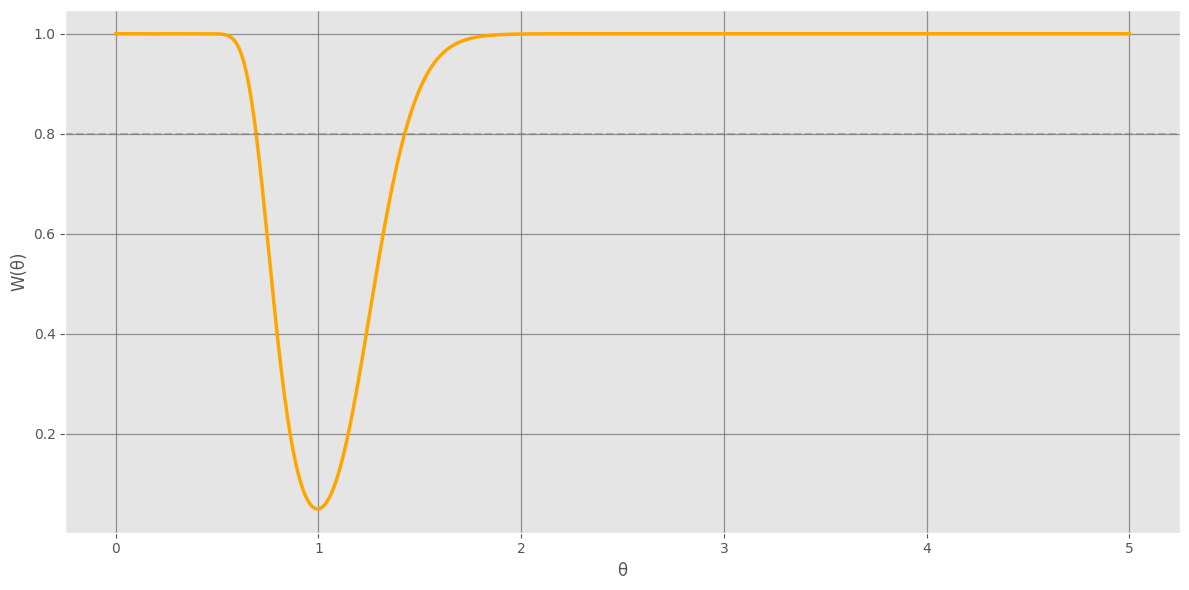

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

np.random.seed(52)
plt.style.use("ggplot")


def calc_sample_variance(std_val, n):
    return (n * (std_val ** 2)) / (n - 1)


alpha = 0.05

std_values = {
    "head_egypt": 5.722,
    "ear_egypt": 4.612,
    "head_europe": 6.161,
    "ear_europe": 5.055,
}

sample_sizes = {
    "egypt": 139,
    "europe": 1000,
}

var_head_egypt = calc_sample_variance(std_values["head_egypt"], sample_sizes["egypt"])
var_ear_egypt = calc_sample_variance(std_values["ear_egypt"], sample_sizes["egypt"])
var_head_europe = calc_sample_variance(std_values["head_europe"], sample_sizes["europe"])
var_ear_europe = calc_sample_variance(std_values["ear_europe"], sample_sizes["europe"])

f_stat_head = np.divide(var_head_egypt, var_head_europe)
f_stat_ear = np.divide(var_ear_egypt, var_ear_europe)

df_egypt = sample_sizes["egypt"] - 1
df_europe = sample_sizes["europe"] - 1

critical_bounds = stats.f.ppf([alpha / 2, 1 - alpha / 2], df_egypt, df_europe)
crit_low, crit_high = critical_bounds

fig, ax = plt.subplots(figsize=(12, 6))

theta_values = np.linspace(start=0.001, stop=5, num=1000)

upper_tail = 1 - stats.f.cdf(crit_high, df_egypt, df_europe, scale=theta_values)
lower_tail = stats.f.cdf(crit_low, df_egypt, df_europe, scale=theta_values)
power_function = upper_tail + lower_tail

ax.plot(theta_values, power_function, linewidth=2.5, color="orange")
ax.set(xlabel="θ", ylabel="W(θ)")
ax.grid(True, color="dimgray", alpha=0.7, linewidth=0.9)
ax.axhline(0.8, linestyle="--", color="gray", alpha=0.5)

plt.tight_layout()
plt.show()